# 02 · Los 4 modelos generativos

Entrena los 4 generadores del taller (Ruido, Gaussiana, RBIG, GAN — ver
`src/generators.py` y la justificación de por qué estos 3 tipos + 1 simple
en `Material_clase/` en el README) sobre el **pool condicional**
construido en el notebook 00: muestras reales
`[retorno_diario, realized_vol, open_30m_ret, close_30m_ret, hl_range]`
de hasta 150 bancos en la ventana real de 2 años.

Los 4 generadores son **incondicionales**: aprenden la distribución
conjunta `(retorno, features)` y solo saben muestrear pares nuevos de esa
conjunta. El paso de condicionar por el retorno diario YA CONOCIDO de cada
día histórico (para el backfill de los 28 años sin 5 min reales) se hace
aparte, en el notebook 03, con el mismo mecanismo de "conditional
matching" para los 4 — así la comparación del notebook 04 mide solo la
calidad de cada generador, no un truco de condicionamiento distinto.

**Importante (fuga de datos):** el pool de entrenamiento de los
generadores excluye tanto el tramo de validación como el de test final
del predictor (`VAL_START_DATE` en adelante) — los generadores nunca ven
esas fechas, ni siquiera indirectamente a través de sus estadísticos.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, features as feat, generators as gen, plotting as pl

RANDOM_STATE = 42

## 1. Cargar el pool condicional y quitar val/test

In [2]:
pool_full = np.load(config.INTERIM_DIR / "conditional_pool.npy")
pool_meta = pd.read_parquet(config.INTERIM_DIR / "conditional_pool_meta.parquet")
assert len(pool_full) == len(pool_meta)

holdout_mask = pool_meta["date"] >= pd.Timestamp(config.VAL_START_DATE)
pool = pool_full[~holdout_mask.values]
print(f"pool total: {len(pool_full):,}  ->  tras quitar val+test: {len(pool):,}")
print("columnas: [log_return, " + ", ".join(feat.INTRADAY_FEATURE_COLS) + "]")

pool total: 53,282  ->  tras quitar val+test: 25,183
columnas: [log_return, realized_vol, open_30m_ret, close_30m_ret, hl_range]


In [3]:
rng = np.random.default_rng(RANDOM_STATE)
shuffled = rng.permutation(len(pool))
n_val = max(int(0.1 * len(pool)), 500)
val_idx, train_idx = shuffled[:n_val], shuffled[n_val:]
pool_train, pool_val = pool[train_idx], pool[val_idx]
print(f"train: {len(pool_train):,}   val (referencia real para comparar): {len(pool_val):,}")

train: 22,665   val (referencia real para comparar): 2,518


## 2. Ruido (modelo simple)

El "ejemplo muy tonto" de `Taller_GANs.ipynb`: recicla muestras reales y
les suma ruido gaussiano proporcional a la escala de cada columna. No
optimiza nada -> no hay curva de convergencia que mostrar aquí (es la
referencia mínima con la que comparar los otros 3).

In [4]:
gen_noise = gen.NoiseGenerator(sigma=0.15, relative=True, random_state=RANDOM_STATE)
gen_noise.fit(pool_train)
synth_noise = feat.clip_nonnegative_pool_columns(gen_noise.sample(50_000))
print("synth_noise:", synth_noise.shape)

synth_noise: (50000, 5)


## 3. Gaussiana multivariante

Igual que `Taller_Gaussian_solution.ipynb`: ajusta `N(mu, Sigma)` sobre el
vector conjunto y muestrea de ella. Cierre analítico -> tampoco hay curva
de "loss" iterativa; el diagnóstico de calidad es comparar directamente la
distribución sintética con la real (más abajo).

In [5]:
gen_gauss = gen.GaussianGenerator(shrinkage=True, random_state=RANDOM_STATE)
gen_gauss.fit(pool_train)
synth_gauss = feat.clip_nonnegative_pool_columns(gen_gauss.sample(50_000))
print("synth_gauss:", synth_gauss.shape, " shrinkage aplicado:", round(gen_gauss.shrinkage_, 3))

synth_gauss: (50000, 5)  shrinkage aplicado: 0.007


## 4. RBIG (Rotation-Based Iterative Gaussianization)

El método con el que la propia diapositiva de teoría del taller (Prof.
Laparra) compara los GAN. A diferencia de la Gaussiana, SÍ itera —
alternando gaussianización marginal + rotación aleatoria — así que sí
tiene un diagnóstico de convergencia real: el exceso de curtosis medio
(|kurtosis-3|) de los datos transformados, que debe tender a 0 a medida
que se acercan a una Normal conjunta.

In [6]:
gen_rbig = gen.RBIGGenerator(n_iters=20, grid_size=400, random_state=RANDOM_STATE)
gen_rbig.fit(pool_train)
synth_rbig = feat.clip_nonnegative_pool_columns(gen_rbig.sample(50_000))
print("synth_rbig:", synth_rbig.shape)

synth_rbig: (50000, 5)


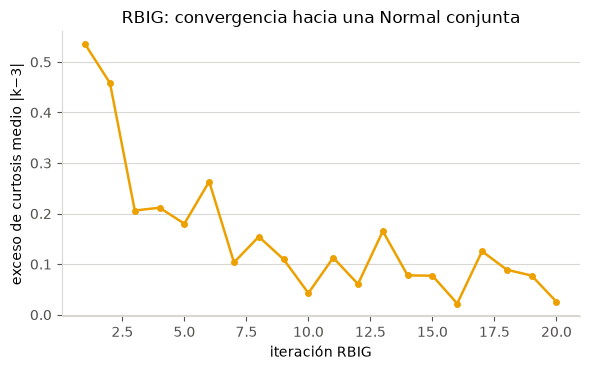

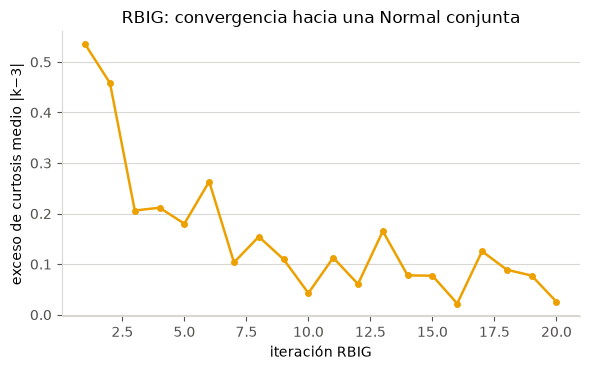

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(
    range(1, len(gen_rbig.excess_kurtosis_history_) + 1),
    gen_rbig.excess_kurtosis_history_,
    marker="o", markersize=4, linewidth=1.8, color=pl.color_for("rbig"),
)
ax.set_xlabel("iteración RBIG")
ax.set_ylabel("exceso de curtosis medio |k−3|")
ax.set_title("RBIG: convergencia hacia una Normal conjunta")
pl.style_axes(ax)
fig.tight_layout()
pl.savefig(fig, "02_rbig_convergencia")
fig

## 5. GAN (requiere TensorFlow)

GAN densa (generador/discriminador feed-forward) en el mismo espíritu
que `Taller_GANs.ipynb`, entrenada sobre el mismo pool. `learning_rate`
bajo y varios pasos de discriminador por paso de generador (ver
`GANGenerator`, `src/generators.py`) son los hiperparámetros que
mejor controlan el colapso de modo característico de un GAN vainilla
con pérdida BCE en un problema de baja dimensión como este (d=5); más
epochs no ayuda una vez alcanzado ese punto — el criterio para elegir
`epochs=1000` fue justo ese, no simplemente "más es mejor". Si
TensorFlow no está disponible, esta celda se salta con un aviso.

.../site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
.../site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


synth_gan: (50000, 5)


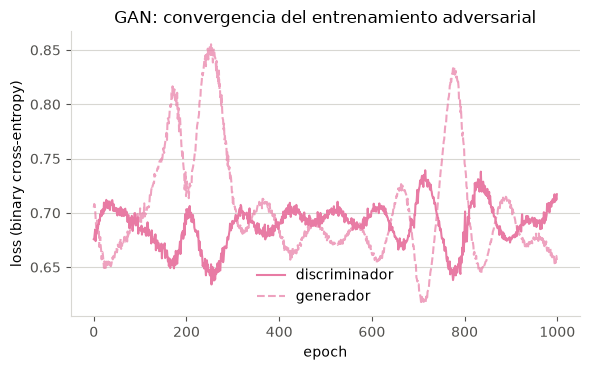

In [8]:
try:
    gen_gan = gen.GANGenerator(
        latent_dim=32, epochs=1000, batch_size=64,
        gen_hidden=(64, 128, 64), disc_hidden=(64, 32),
        learning_rate=1e-4, d_steps_per_g=2, random_state=RANDOM_STATE,
    )
    gen_gan.fit(pool_train)
    synth_gan = feat.clip_nonnegative_pool_columns(gen_gan.sample(50_000))
    print("synth_gan:", synth_gan.shape)

    fig, ax = plt.subplots(figsize=(6, 3.8))
    ax.plot(gen_gan.history_["d_loss"], label="discriminador", color=pl.color_for("gan"), linewidth=1.5)
    ax.plot(gen_gan.history_["g_loss"], label="generador", color=pl.color_for("gan"),
            linewidth=1.5, linestyle="--", alpha=0.7)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss (binary cross-entropy)")
    ax.set_title("GAN: convergencia del entrenamiento adversarial")
    ax.legend(frameon=False)
    pl.style_axes(ax)
    fig.tight_layout()
    pl.savefig(fig, "02_gan_convergencia")
    GAN_AVAILABLE = True
except ImportError as e:
    print(f"[AVISO] GAN no disponible en este entorno: {e}")
    synth_gan = None
    GAN_AVAILABLE = False

## 6. Diagnóstico: ¿cada generador reproduce la distribución real?

Histograma real (holdout) vs. sintético para cada una de las 4 features,
una fila por generador.

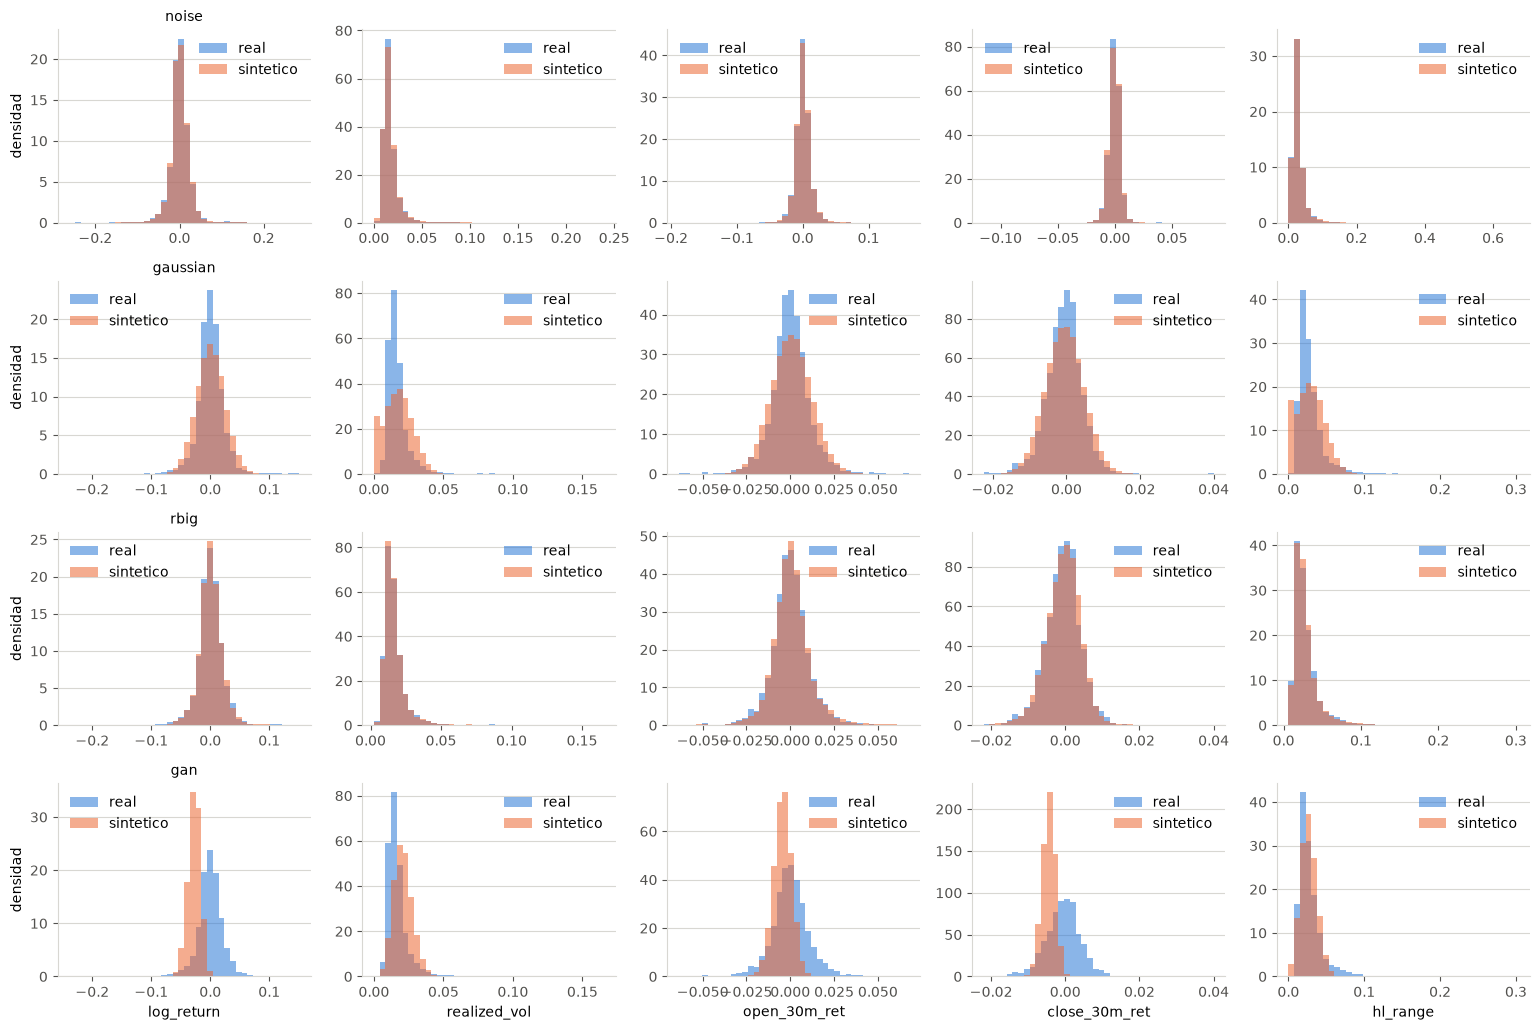

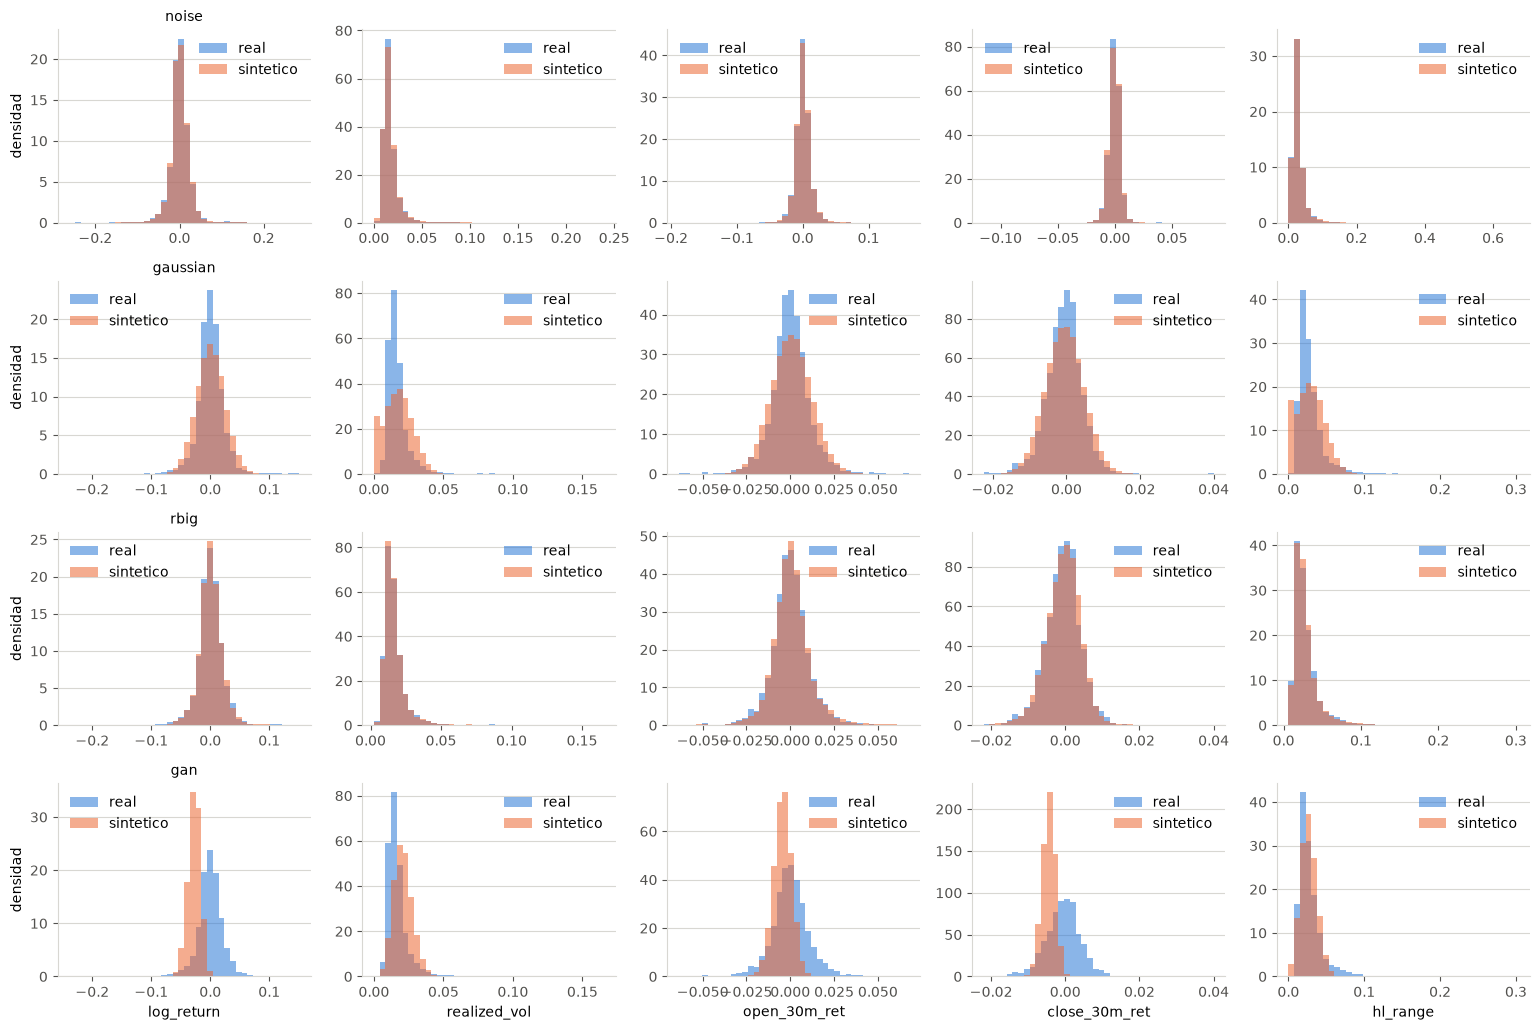

In [9]:
synthetic_pools = {"noise": synth_noise, "gaussian": synth_gauss, "rbig": synth_rbig}
if GAN_AVAILABLE:
    synthetic_pools["gan"] = synth_gan

cols = ["log_return", *feat.INTRADAY_FEATURE_COLS]
fig, axes = plt.subplots(
    len(synthetic_pools), len(cols), figsize=(3.1 * len(cols), 2.6 * len(synthetic_pools))
)
for i, (name, synth) in enumerate(synthetic_pools.items()):
    for j, col in enumerate(cols):
        ax = axes[i, j]
        pl.plot_real_vs_synthetic_hist(
            pool_val[:, j], synth[:, j], xlabel=col if i == len(synthetic_pools) - 1 else "",
            title=name if j == 0 else "", ax=ax, bins=40,
        )
        if j > 0:
            ax.set_ylabel("")
fig.tight_layout()
pl.savefig(fig, "02_real_vs_sintetico_por_generador")
fig

## 7. Diagnóstico: matriz de correlación real vs. sintética

¿Cada generador reproduce también la DEPENDENCIA entre retorno y features
(no solo las marginales de arriba)? Distancia de Frobenius entre la
matriz de correlación real (holdout) y la de cada sintético — cuanto más
baja, mejor conserva el generador la estructura conjunta.

In [10]:
corr_real = np.corrcoef(pool_val.T)
rows = []
for name, synth in synthetic_pools.items():
    corr_synth = np.corrcoef(synth.T)
    dist = float(np.linalg.norm(corr_real - corr_synth))
    rows.append({"generador": name, "dist_frobenius_corr": dist})
corr_quality = pd.DataFrame(rows).set_index("generador").sort_values("dist_frobenius_corr")
corr_quality.to_csv(config.TABLES_DIR / "02_calidad_correlacion_generadores.csv")
corr_quality

,dist_frobenius_corr
generador,
noise,0.385964
gaussian,0.403699
rbig,0.479580
gan,1.273807


## 8. Guardar los pools sintéticos (`datos/interim/`, gitignored)

El notebook 03 los usa para el backfill condicional de los 28 años sin
5 minutos reales.

In [11]:
for name, synth in synthetic_pools.items():
    np.save(config.INTERIM_DIR / f"synthetic_pool_{name}.npy", synth)
print("Guardados:", list(synthetic_pools.keys()))

Guardados: ['noise', 'gaussian', 'rbig', 'gan']
